Import necessary libraries

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [26]:
df = pd.read_csv("/content/balanced_student_data.csv")

Basic Data Shape and Info

In [27]:
print("Dataset Shape (Rows, Columns):", df.shape)

Dataset Shape (Rows, Columns): (99999, 8)


In [28]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   StudentID       99999 non-null  object
 1   Maths           99999 non-null  int64 
 2   Science         99999 non-null  int64 
 3   English         99999 non-null  int64 
 4   History         99999 non-null  int64 
 5   Computer        99999 non-null  int64 
 6   Attendance(%)   99999 non-null  int64 
 7   Recommendation  99999 non-null  object
dtypes: int64(6), object(2)
memory usage: 6.1+ MB
None


In [29]:
print("\nFirst 5 Rows of the Dataset:")
print(df.head())


First 5 Rows of the Dataset:
  StudentID  Maths  Science  English  History  Computer  Attendance(%)  \
0     S0001     77       67       79       92        66             82   
1     S0002     93       81       62       78        63             80   
2     S0003     73       41       44       61        54             88   
3     S0004     56       48       91       66        71             70   
4     S0005     61       71       52       75        60             82   

      Recommendation  
0  Needs Improvement  
1  Needs Improvement  
2  Needs Improvement  
3  Needs Improvement  
4  Needs Improvement  


Summary Statistics

In [30]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
              Maths       Science       English       History      Computer  \
count  99999.000000  99999.000000  99999.000000  99999.000000  99999.000000   
mean      64.988600     64.977410     65.024720     65.014480     65.009330   
std       18.205961     18.199933     18.206454     18.193445     18.204339   
min       30.000000     30.000000     30.000000     30.000000     30.000000   
25%       51.000000     51.000000     51.000000     51.000000     51.000000   
50%       65.000000     65.000000     66.000000     66.000000     66.000000   
75%       79.000000     79.000000     79.000000     79.000000     79.000000   
max      100.000000    100.000000    100.000000    100.000000    100.000000   

       Attendance(%)  
count   99999.000000  
mean       86.519975  
std         9.091648  
min        50.000000  
25%        81.000000  
50%        87.000000  
75%        93.000000  
max       100.000000  


Check for Missing Values

In [31]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
StudentID         0
Maths             0
Science           0
English           0
History           0
Computer          0
Attendance(%)     0
Recommendation    0
dtype: int64


Distribution of Target Variable (Recommendation)

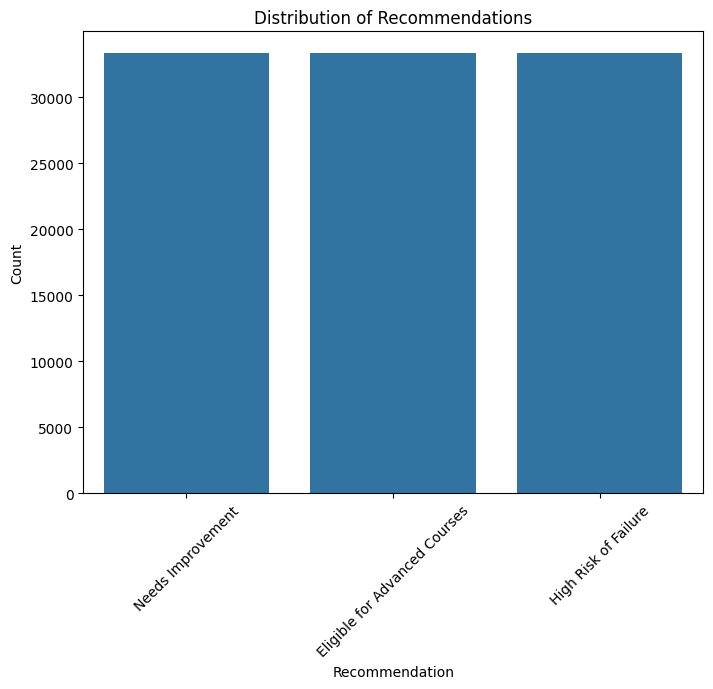

In [32]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Recommendation', data=df)
plt.title('Distribution of Recommendations')
plt.xlabel('Recommendation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Distribution of Features

<Figure size 1200x800 with 0 Axes>

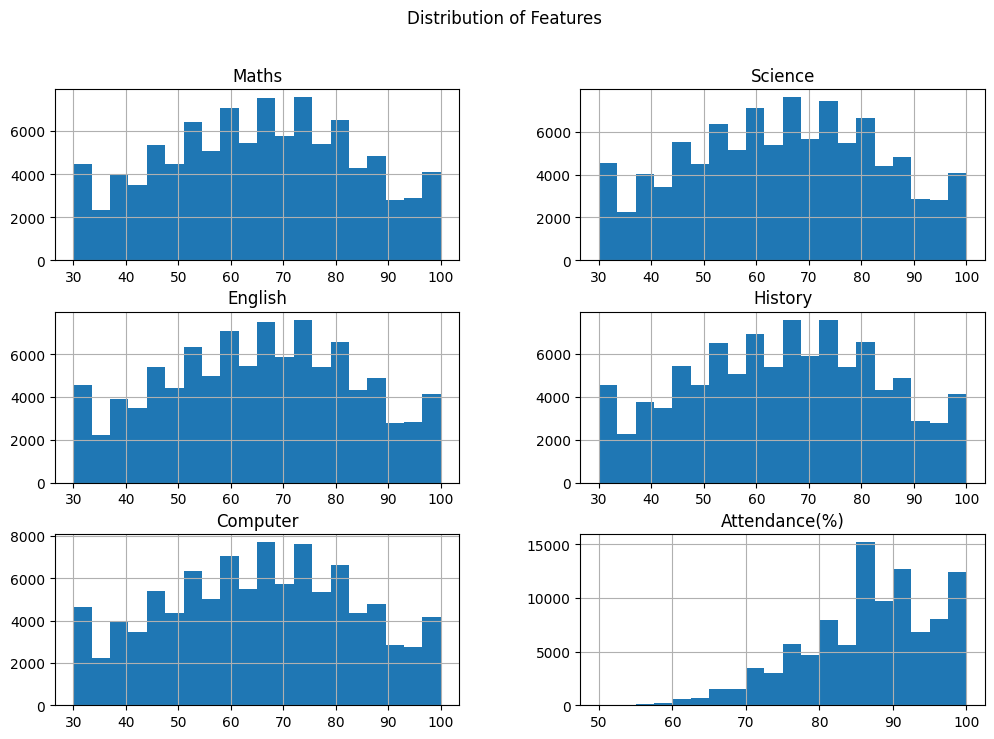

In [33]:
plt.figure(figsize=(12, 8))
df.hist(bins=20, figsize=(12, 8))
plt.suptitle('Distribution of Features')
plt.show()

Box Plots for Outlier Detection

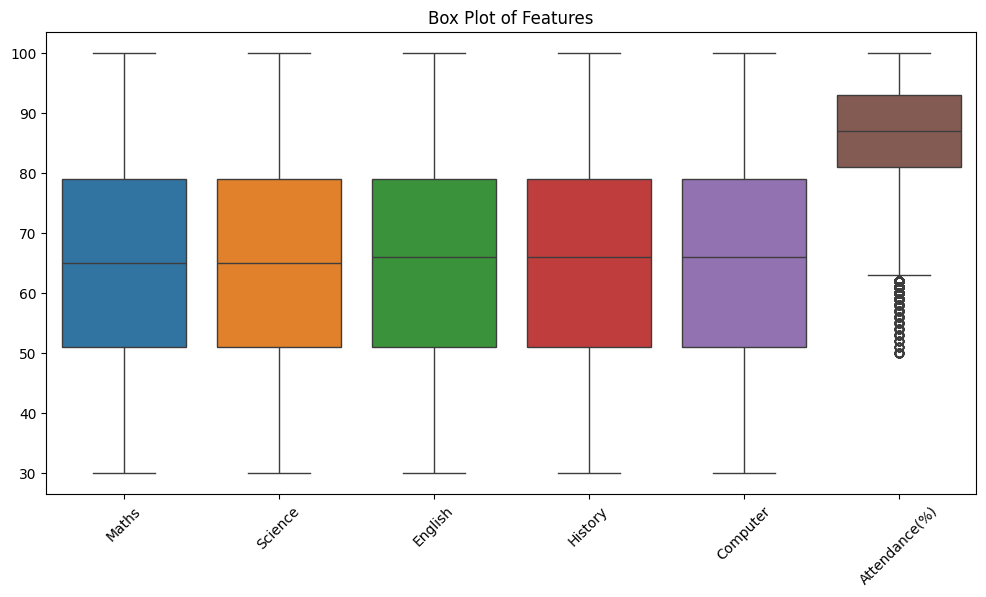

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['Maths', 'Science', 'English', 'History', 'Computer', 'Attendance(%)']])
plt.title('Box Plot of Features')
plt.xticks(rotation=45)
plt.show()

Correlation Matrix

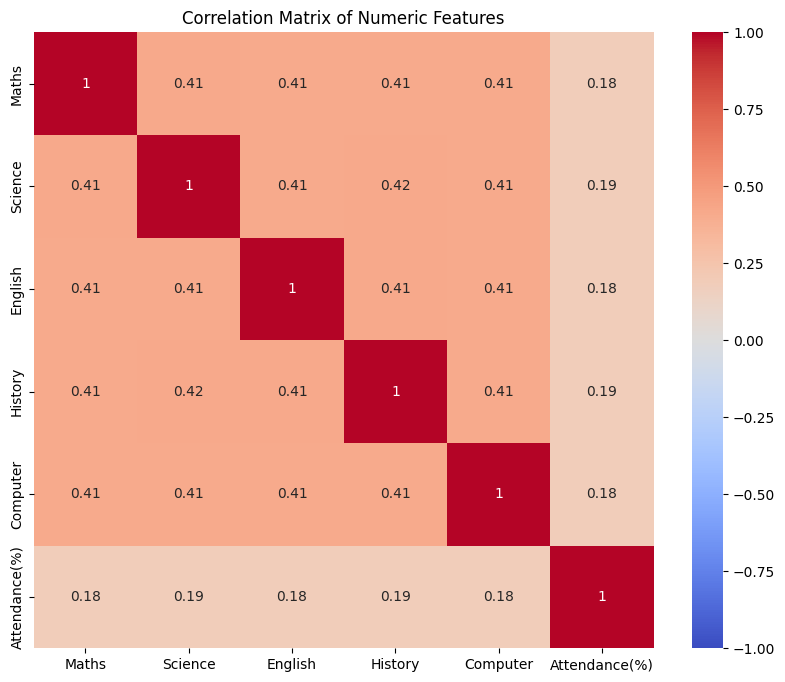

In [35]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

Features and target

In [36]:
X = df[["Maths", "Science", "English", "History", "Computer", "Attendance(%)"]]
y = df["Recommendation"]

Encode target if needed

In [37]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Train-test split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

Train the model

In [39]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Evaluate

In [40]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                               precision    recall  f1-score   support

Eligible for Advanced Courses       0.96      1.00      0.98      6659
         High Risk of Failure       0.99      1.00      0.99      6600
            Needs Improvement       1.00      0.95      0.97      6741

                     accuracy                           0.98     20000
                    macro avg       0.98      0.98      0.98     20000
                 weighted avg       0.98      0.98      0.98     20000



Save the trained model

In [41]:
with open("student_recommendation_model.pkl", "wb") as f:
    pickle.dump(clf, f)

Save the LabelEncoder too (important for decoding predictions)

In [42]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

Load the model & LabelEncoder then predict

In [43]:
with open("/content/student_recommendation_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("/content/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

sample_input = [[40, 32, 20, 24, 15, 12]]  # Marks + Attendance
predicted_class = model.predict(sample_input)
predicted_label = label_encoder.inverse_transform(predicted_class)

print("Predicted Recommendation:", predicted_label[0])

Predicted Recommendation: High Risk of Failure


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
